<!-- milestone-3 analaysis
Milestone 3: Route, Cancellation, and Seasonal Insights -->

In [19]:
#Week 5: Route and Airport-Level Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("../Data/Processed/flights_2009_processed.csv")


In [20]:
import os 
os.getcwd

<function nt.getcwd()>

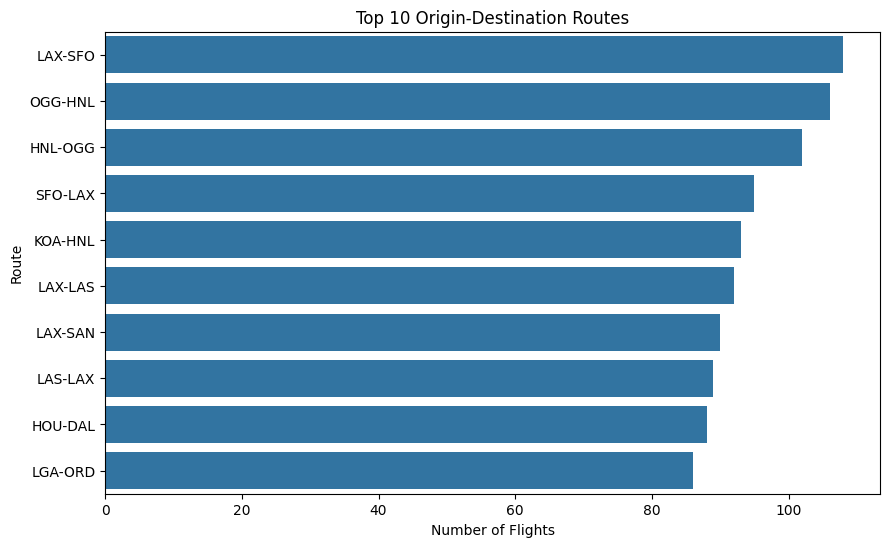

In [21]:
# Top 10 origin-destination pairs 
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_routes.values, y=top_routes.index)

plt.title("Top 10 Origin-Destination Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.show()

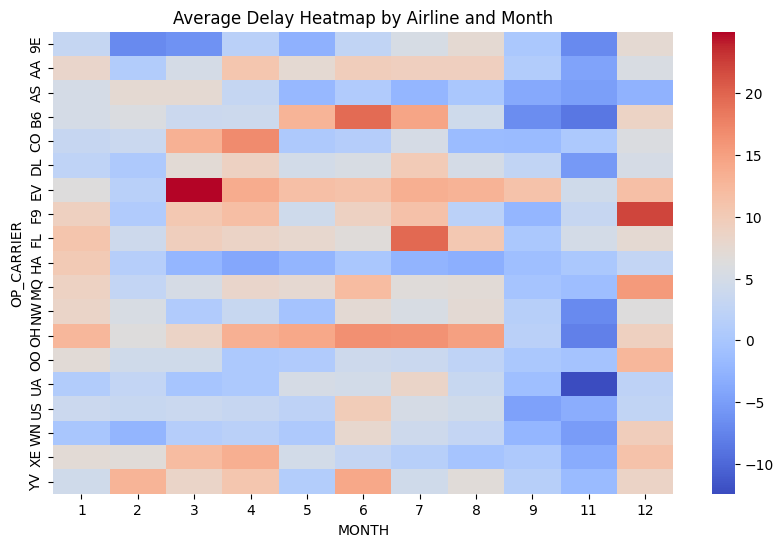

In [23]:
# Delay Heatmap by Airline
pivot = df.pivot_table(values='ARR_DELAY',
                       index='OP_CARRIER',
                       columns='MONTH',
                       aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="coolwarm")

plt.title("Average Delay Heatmap by Airline and Month")
plt.show()

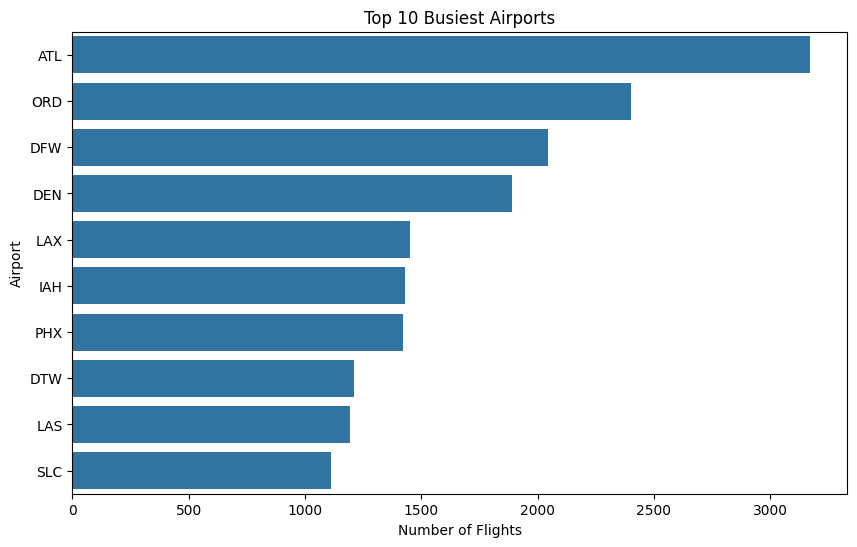

In [ ]:
# Delay Heatmap by Airline
# This chart shows airports with the highest number of departing flights.
busiest_airports = df['ORIGIN'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=busiest_airports.values, y=busiest_airports.index)

plt.title("Top 10 Busiest Airports")
plt.xlabel("Number of Flights")
plt.ylabel("Airport")
plt.show()

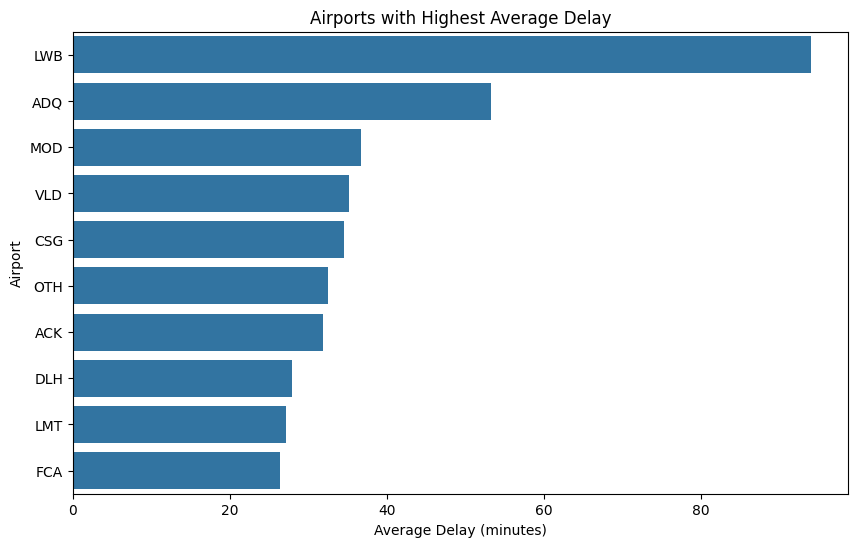

In [25]:
# Average Delay by Airport
# hows which airports experience higher delay
airport_delay = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=airport_delay.values, y=airport_delay.index)

plt.title("Airports with Highest Average Delay")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Airport")
plt.show()

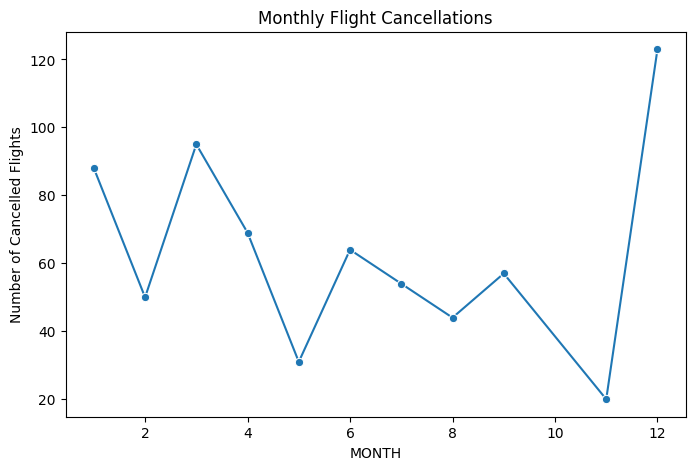

In [29]:
# Monthly Cancellation Trend
# Monthly Cancellation Trend
monthly_cancel = df.groupby('MONTH')['CANCELLED'].sum()

plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_cancel.index, y=monthly_cancel.values, marker="o")

plt.title("Monthly Flight Cancellations")
plt.xlabel("MONTH")
plt.ylabel("Number of Cancelled Flights")
plt.show()

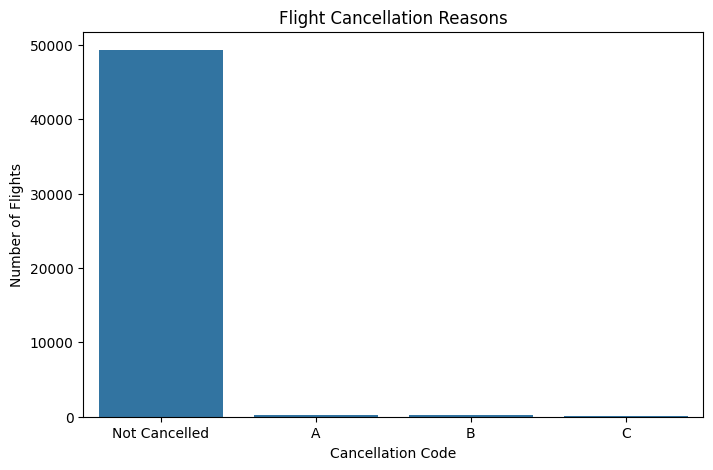

In [30]:
# Cancellation Reasons
# Cancellation Reasons
cancel_reason = df['CANCELLATION_CODE'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=cancel_reason.index, y=cancel_reason.values)

plt.title("Flight Cancellation Reasons")
plt.xlabel("Cancellation Code")
plt.ylabel("Number of Flights")
plt.show()

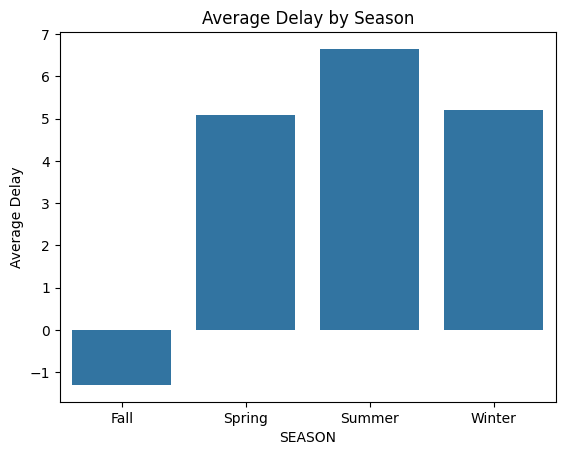

In [35]:
# Seasonal Delay Analysis
season_delay = df.groupby('SEASON')['ARR_DELAY'].mean()

sns.barplot(x=season_delay.index, y=season_delay.values)

plt.title("Average Delay by Season")
plt.xlabel("SEASON")
plt.ylabel("Average Delay")
plt.show()



<!-- INSIGHTS -->
• Certain routes experience significantly higher flight traffic.
• Some airports experience higher average delays.
• Carrier-related issues contribute significantly to cancellations.
• Seasonal variations influence flight delays.

<!-- week-6 Seasonal cancellation -->

<!-- Monthly cancellation trends -->


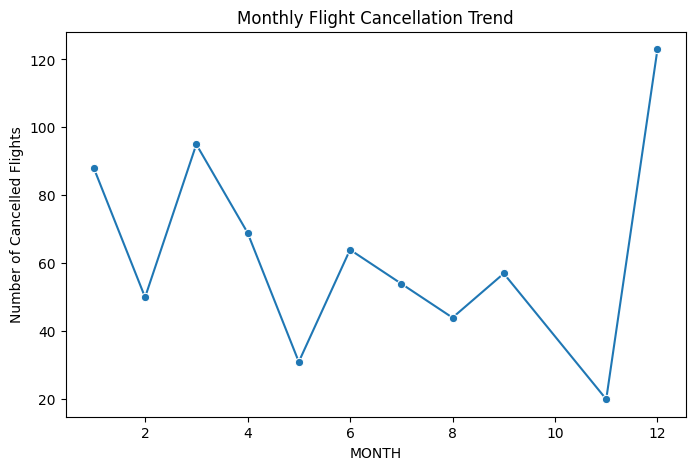

In [37]:
# <!-- Monthly cancellation trends -->
# how cancellations changes across months...
monthly_cancel = df.groupby('MONTH')['CANCELLED'].sum()

plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_cancel.index, y=monthly_cancel.values, marker='o')

plt.title("Monthly Flight Cancellation Trend")
plt.xlabel("MONTH")
plt.ylabel("Number of Cancelled Flights")
plt.show()

Example Insights....
• Flight cancellations vary across months, indicating seasonal operational challenges.
• Weather-related cancellations contribute significantly in certain periods.
• Winter months tend to show higher cancellation rates due to adverse weather conditions

In [39]:
# Holidays Impact
df['Holiday_Season'] = df['MONTH'].apply(
    lambda x: 'Holiday/Winter' if x in [11,12,1] else 'Normal'
)

In [42]:
# HOLIDAY DELAY

holiday_delay = df.groupby('Holiday_Season')['ARR_DELAY'].mean()

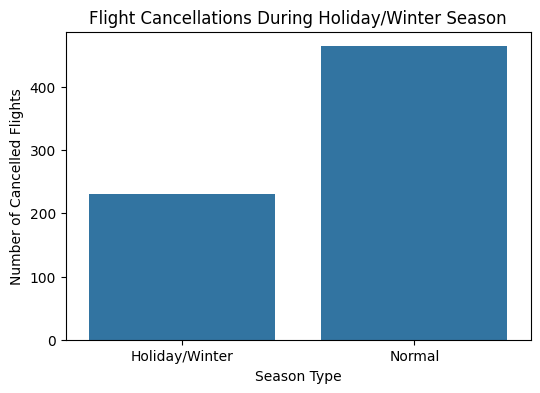

In [45]:
# COMPARE CANCELLATION

holiday_cancel = df.groupby('Holiday_Season')['CANCELLED'].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=holiday_cancel.index, y=holiday_cancel.values)

plt.title("Flight Cancellations During Holiday/Winter Season")
plt.xlabel("Season Type")
plt.ylabel("Number of Cancelled Flights")
plt.show()


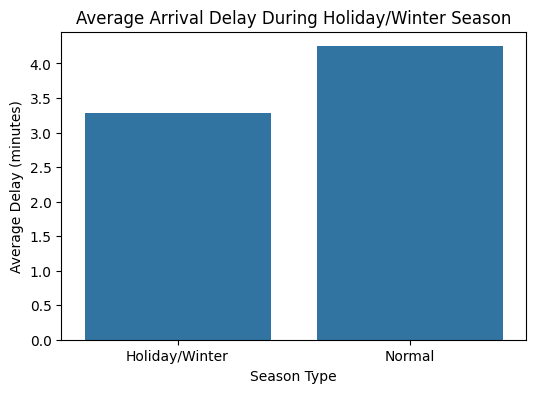

In [44]:
# COMPARE DELAYS

holiday_delay = df.groupby('Holiday_Season')['ARR_DELAY'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=holiday_delay.index, y=holiday_delay.values)

plt.title("Average Arrival Delay During Holiday/Winter Season")
plt.xlabel("Season Type")
plt.ylabel("Average Delay (minutes)")
plt.show()

--INSIGHTS FOR HOLIDAY IMPACTS

Flights during the holiday and winter season show a higher number of
cancellations and delays compared to other months.

This may be due to increased travel demand during holidays such as
Thanksgiving and Christmas, as well as weather disruptions during
winter months.